<a href="https://colab.research.google.com/github/Victorpc132/ProjetosPythonRauber/blob/main/03_Exemplo_de_sele%C3%A7%C3%A3o_de_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape original dos dados: (569, 30)

Top 10 Features selecionadas (Qui-quadrado):
['mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'worst radius', 'worst perimeter', 'worst area', 'worst concavity', 'worst concave points']

Top 10 Features selecionadas (RFE):
['mean radius', 'mean compactness', 'mean concavity', 'texture error', 'worst radius', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry']

Top 10 Features selecionadas (Random Forest):
['worst perimeter', 'worst concave points', 'worst area', 'mean concave points', 'worst radius', 'mean concavity', 'mean area', 'mean radius', 'mean perimeter', 'area error']


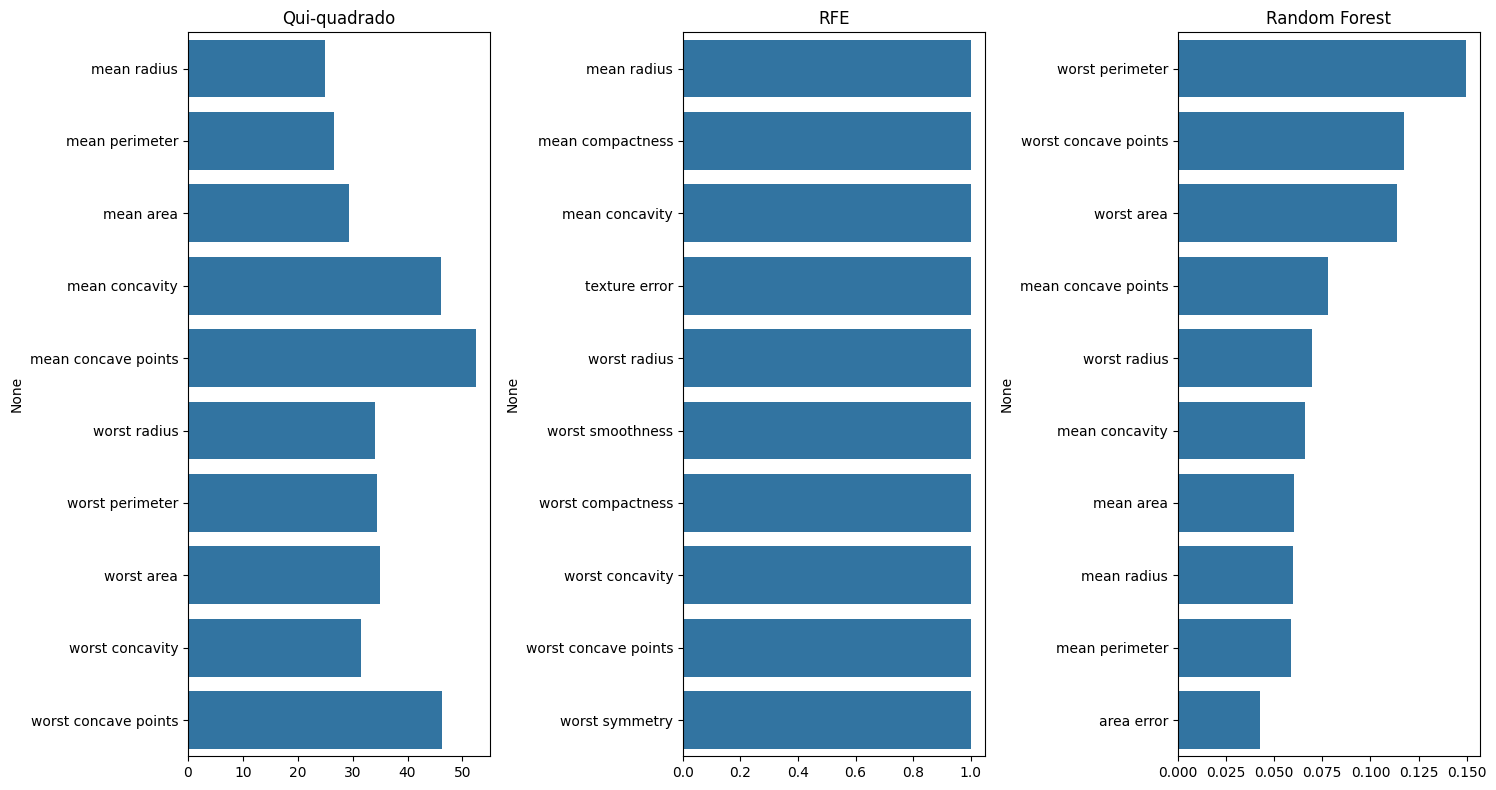

In [ ]:
# Esse código cobre três técnicas populares de seleção de features:

    # Método Estatístico (Qui-quadrado): seleciona as features mais correlacionadas com a variável alvo.
    # RFE (Recursive Feature Elimination): remove recursivamente as menos importantes com base em uma Regressão Logística.
    # Random Forest: mede a importância das features com base no ganho de informação.



import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dataset de exemplo (Câncer de mama)
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Shape original dos dados:", df.shape)

# Normalizar os dados para o teste qui-quadrado
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# 1. Seleção de Features - Método Estatístico (Qui-quadrado)
k = 10
selector = SelectKBest(score_func=chi2, k=k)
X_new = selector.fit_transform(df_scaled, y)
selected_features = df.columns[selector.get_support()]

print("\nTop 10 Features selecionadas (Qui-quadrado):")
print(selected_features.tolist())

# 2. Seleção de Features - Recursive Feature Elimination (RFE)
model = LogisticRegression(max_iter=5000)
rfe = RFE(estimator=model, n_features_to_select=k)
X_rfe = rfe.fit_transform(df, y)
rfe_features = df.columns[rfe.support_]

print("\nTop 10 Features selecionadas (RFE):")
print(rfe_features.tolist())

# 3. Importância de Features - Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(df, y)
feature_importances = pd.Series(rf.feature_importances_, index=df.columns)
top_features_rf = feature_importances.nlargest(k).index

print("\nTop 10 Features selecionadas (Random Forest):")
print(top_features_rf.tolist())

# Comparação visual
plt.figure(figsize=(15, 8))

# Qui-quadrado
plt.subplot(1, 3, 1)
sns.barplot(x=selector.scores_[selector.get_support()], y=selected_features)
plt.title('Qui-quadrado')

# RFE
plt.subplot(1, 3, 2)
sns.barplot(x=rfe.ranking_[rfe.support_], y=rfe_features)
plt.title('RFE')

# Random Forest
plt.subplot(1, 3, 3)
sns.barplot(x=feature_importances.nlargest(k).values, y=top_features_rf)
plt.title('Random Forest')

plt.tight_layout()
plt.show()
